**UTS Analisis Data Tidak Terstruktur**

Nabila Frylia Puteri (2306210462)

Program Studi Matematika, Fakultas Matematika dan Ilmu Pengetahuan Alam, Universitas Indonesia

# Import Library

In [1]:
!pip install transformers

In [2]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Viz
import matplotlib.pyplot as plt
import re

# NLP
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

#EDA
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# MODEL
#Model IndoBERT
import random
import torch
import torch.nn.functional as F
from torch import optim
from tqdm import tqdm
import torch
from torch import optim

from tqdm.autonotebook import tqdm

from torch.utils.data import Dataset, DataLoader
from transformers import BertForSequenceClassification, BertConfig, BertTokenizer

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Load Dataset

In [3]:
# Download latest version
path = kagglehub.dataset_download("falgunipatel19/biomedical-text-publication-classification")

print("Path to dataset files:", path)

100%|██████████| 55.9M/55.9M [00:00<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/falgunipatel19/biomedical-text-publication-classification/versions/1


In [4]:
df = pd.read_csv(path + "/alldata_1_for_kaggle.csv", encoding='latin-1', index_col=0)

df.head()

,0,a
0,Thyroid_Cancer,Thyroid surgery in children in a single insti...
1,Thyroid_Cancer,""" The adopted strategy was the same as that us..."
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...
3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...
4,Thyroid_Cancer,This study aimed to investigate serum matrix ...


In [5]:
df = df.rename(columns={
    "0": "label",
    "a": "text"
})

In [6]:
# Ambil 3 contoh kalimat per kategori
for label in df['label'].unique():
    print(f"\n Contoh kalimat{label}:")
    sample_texts = df[df['label'] == label]['text'].sample(3, random_state=42)
    for text in sample_texts:
        print(f"- {text}")


 Contoh kalimatThyroid_Cancer:
-  prevalence of pathogenic variants in DnA damage response and repair genes in patients undergoing cancer risk assessment and reporting a personal history of earlyonset renal cancerTiffiney a0R a0Hartman12 a0Elena a0V a0Demidova345 a0Randy a0W a0Lesh6 a0Lily a0Hoang7 a0Marcy Richardson7 a0Andrea a0Forman8 a0Lisa a0Kessler1 a0Virginia a0Speare7 a0Erica a0A a0Golemis4 a0Michael a0J a0Hall38 a0Mary a0B a0Daly38  Sanjeevani Arora3Pathogenic a0variants a0PVs a0in a0multiple a0genes a0are a0known a0to a0increase a0the a0risk a0of a0earlyonset a0renal a0cancer a0eoRC a0However a0many a0eoRC a0patients a0lack a0PVs a0in a0RCspecific a0genes a0thus a0their a0genetic a0risk a0remains a0undefined a0Here a0we a0determine a0if a0PVs a0in a0DNA a0damage a0response a0and a0repair a0DDRR a0genes a0are a0enriched a0in a0eoRC a0patients a0undergoing a0cancer a0risk a0assessment a0Retrospective a0review a0of a0deidentified a0results a0from a0 a0eoRC a0patients a0undergoi

# Proporsi Variabel Target

In [7]:
for label in np.unique(df['label']):
    print(label)

Colon_Cancer
Lung_Cancer
Thyroid_Cancer


<Axes: xlabel='label'>

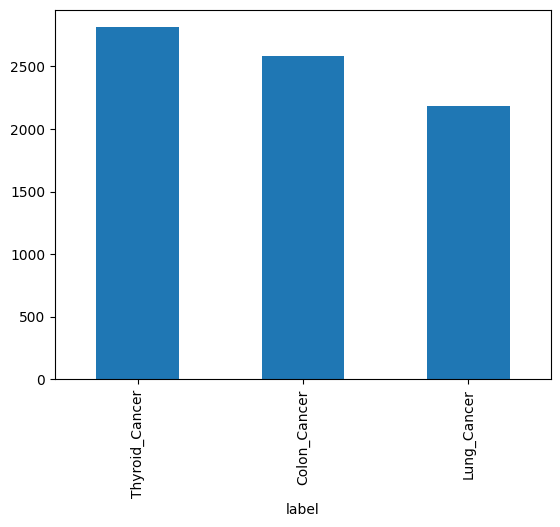

In [8]:
df['label'].value_counts().sort_values(ascending=False).plot(kind='bar')

<Axes: ylabel='count'>

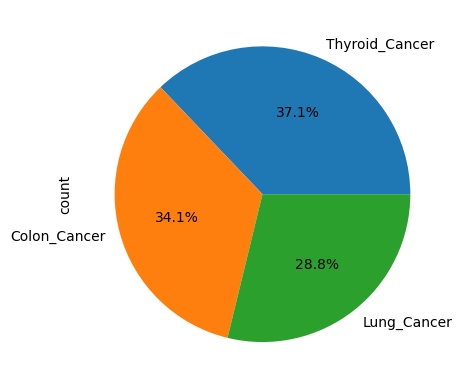

In [9]:
df['label'].value_counts().sort_values(ascending=False).plot(kind='pie',autopct='%1.1f%%')

# Pre-processing

In [10]:
def clean_text(text):
    text = str(text)
    text = text.replace('\xa0', ' ')
    text = re.sub(r'a0', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # Corrected: Replaced '[^\u0000-\u007F]+' with '[^\x00-\x7F]+'
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"[\"']", "", text)
    return text.strip()

def to_lower(text):
    return text.lower()

def preprocess(df):
    df_pp = df.copy()
    df_pp['text'] = df_pp['text'].astype(str).apply(clean_text)
    df_pp['text'] = df_pp['text'].apply(to_lower)
    df_pp['text'].replace('', np.nan, inplace=True)
    df_pp.dropna(subset=['text'], inplace=True)
    df_pp.reset_index(drop=True, inplace=True)
    return df_pp

# Jalankan
df_v1 = preprocess(df)

/tmp/ipykernel_4992/1587908458.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pp['text'].replace('', np.nan, inplace=True)


In [11]:
def normalize_text(text):
    tokens = word_tokenize(text)
    # contoh: hapus token kosong / aneh
    tokens = [t for t in tokens if len(t) > 1]
    return " ".join(tokens)
def preprocess_v2(df):
    df_pp = df.copy()
    df_pp['text'] = df_pp['text'].apply(normalize_text)
    df_pp['text'].replace('', np.nan, inplace=True)
    df_pp.dropna(subset=['text'], inplace=True)
    return df_pp

# Eksekusi
df_v2 = preprocess_v2(df_v1)

/tmp/ipykernel_4992/3224311171.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pp['text'].replace('', np.nan, inplace=True)


In [12]:
df_v2

,label,text
0,Thyroid_Cancer,thyroid surgery in children in single institut...
1,Thyroid_Cancer,the adopted strategy was the same as that used...
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis brin...
3,Thyroid_Cancer,solitary plasmacytoma sp of the skull is an un...
4,Thyroid_Cancer,this study aimed to investigate serum matrix m...
...,...,...
7565,Colon_Cancer,we report the case of 24yearold man who presen...
7566,Colon_Cancer,among synchronous colorectal cancers scrcs rep...
7567,Colon_Cancer,the heterogeneity of cancer cells is generally...
7568,Colon_Cancer,adipogenesis is the process through which mese...


# EDA

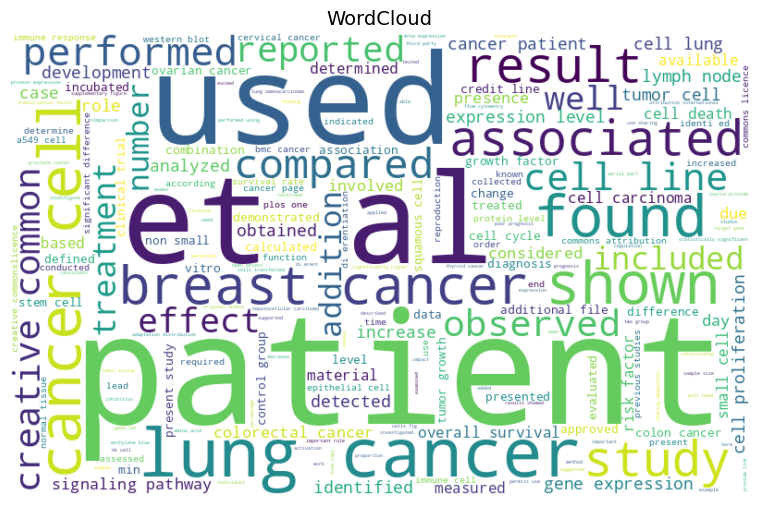

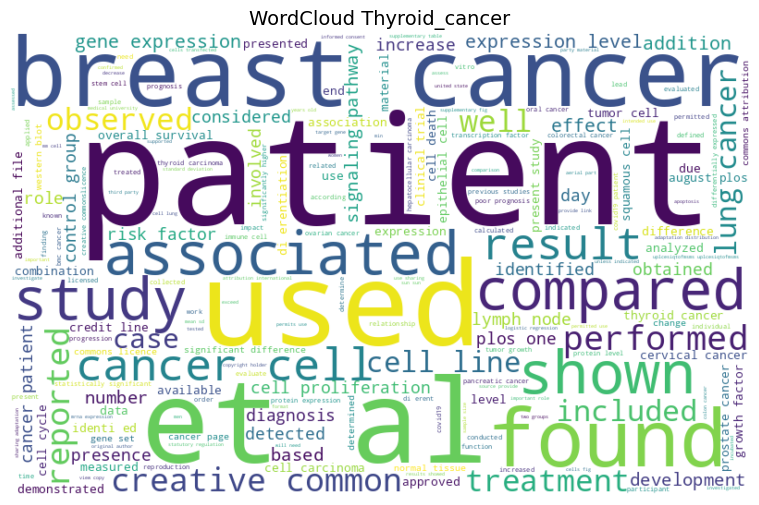

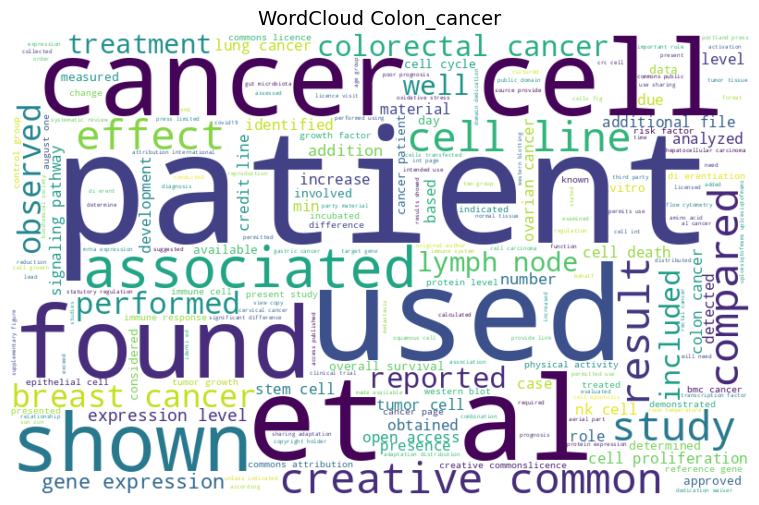

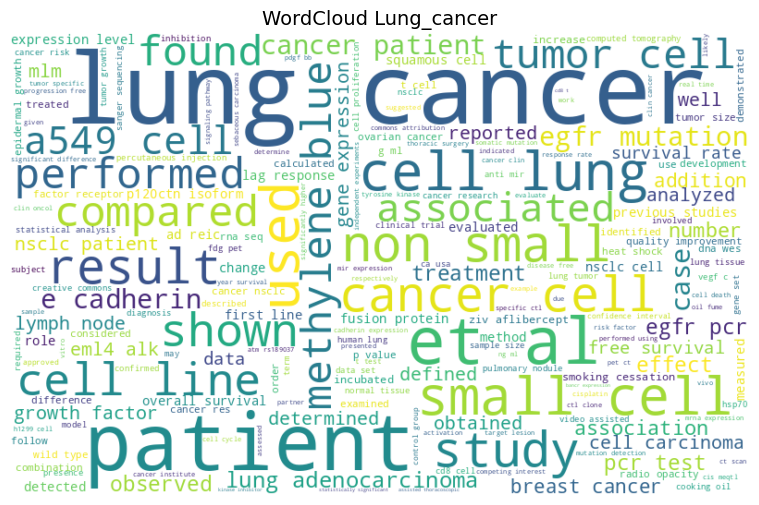

In [13]:
# Fungsi bantu untuk menampilkan WordCloud
def show_wordcloud(text, title=None):
    wordcloud = WordCloud(width=800, height=500, background_color='white').generate(text)
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    if title:
        plt.title(title, fontsize=14)
    plt.show()

# WordCloud semua data
all_text = " ".join(df_v2['text'])
show_wordcloud(all_text, title="WordCloud")

# WordCloud per kategori sentimen
for label in df_v2['label'].unique():
    text = " ".join(df_v2[df_v2['label'] == label]['text'])
    show_wordcloud(text, title=f"WordCloud {label.capitalize()}")

# Splitting

In [14]:
# train val split
train_set, val_set = train_test_split(df_v2, test_size=0.3, stratify=df_v2.label, random_state=1)
val_set, test_set = train_test_split(val_set, test_size=0.33, stratify=val_set.label, random_state=1)

print(f'Train shape: {train_set.shape}')
print(f'Val shape: {val_set.shape}')
print(f'Test shape: {test_set.shape}')

Train shape: (5299, 2)
Val shape: (1521, 2)
Test shape: (750, 2)


In [15]:
train_set[['text', 'label']].to_csv('train_set.tsv', sep='\t', header=None, index=False)
val_set[['text', 'label']].to_csv('val_set.tsv', sep='\t', header=None, index=False)
test_set[['text', 'label']].to_csv('test_set.tsv', sep='\t', header=None, index=False)

# Modelling

In [16]:
df['label'].unique()

array(['Thyroid_Cancer', 'Colon_Cancer', 'Lung_Cancer'], dtype=object)

In [17]:
class DocumentDataset(Dataset):
    # Static constant variable
    LABEL2INDEX = {'Thyroid_Cancer':0, 'Colon_Cancer':1, 'Lung_Cancer':2}
    INDEX2LABEL = {0:'Thyroid_Cancer', 1:'Colon_Cancer', 2:'Lung_Cancer'}
    NUM_LABELS = 3

    def load_dataset(self, path):
        df = pd.read_csv(path, sep='\t', header=None)
        df.columns = ['text','label']
        return df

    def __init__(self, dataset_path, tokenizer, no_special_token=False, *args, **kwargs):
        self.data = self.load_dataset(dataset_path)
        self.tokenizer = tokenizer
        self.no_special_token = no_special_token

    def __getitem__(self, index):
        data = self.data.loc[index,:]
        text, sentiment_str = data['text'], data['label']
        sentiment = self.LABEL2INDEX[sentiment_str] # Convert string label to integer ID
        subwords = self.tokenizer.encode(text, add_special_tokens=not self.no_special_token)
        return np.array(subwords), np.array(sentiment), data['text']

    def __len__(self):
        return len(self.data)

class DocumentDataLoader(DataLoader):
    def __init__(self, max_seq_len=512, *args, **kwargs):
        super(DocumentDataLoader, self).__init__(*args, **kwargs)
        self.collate_fn = self._collate_fn
        self.max_seq_len = max_seq_len

    def _collate_fn(self, batch):
        batch_size = len(batch)
        max_seq_len = max(map(lambda x: len(x[0]), batch))
        max_seq_len = min(self.max_seq_len, max_seq_len)

        subword_batch = np.zeros((batch_size, max_seq_len), dtype=np.int64)
        mask_batch = np.zeros((batch_size, max_seq_len), dtype=np.float32)
        sentiment_batch = np.zeros((batch_size, 1), dtype=np.int64)

        seq_list = []
        for i, (subwords, sentiment, raw_seq) in enumerate(batch):
            subwords = subwords[:max_seq_len]
            subword_batch[i,:len(subwords)] = subwords
            mask_batch[i,:len(subwords)] = 1
            sentiment_batch[i,0] = sentiment

            seq_list.append(raw_seq)

        return subword_batch, mask_batch, sentiment_batch, seq_list

In [18]:
# Forward function for sequence classification
def forward_sequence_classification(model, batch_data, i2w, is_test=False, device='cpu', **kwargs):
    # Unpack batch data
    if len(batch_data) == 3:
        (subword_batch, mask_batch, label_batch) = batch_data
        token_type_batch = None
    elif len(batch_data) == 4:
        (subword_batch, mask_batch, token_type_batch, label_batch) = batch_data

    # Prepare input & label
    subword_batch = torch.LongTensor(subword_batch)
    mask_batch = torch.FloatTensor(mask_batch)
    token_type_batch = torch.LongTensor(token_type_batch) if token_type_batch is not None else None
    label_batch = torch.LongTensor(label_batch)

    if device == "cuda":
        subword_batch = subword_batch.cuda()
        mask_batch = mask_batch.cuda()
        token_type_batch = token_type_batch.cuda() if token_type_batch is not None else None
        label_batch = label_batch.cuda()

    # Forward model
    outputs = model(subword_batch, attention_mask=mask_batch, token_type_ids=token_type_batch, labels=label_batch)
    loss, logits = outputs[:2]

    # generate prediction & label list
    list_hyp = []
    list_label = []
    hyp = torch.topk(logits, 1)[1]
    for j in range(len(hyp)):
        list_hyp.append(i2w[hyp[j].item()])
        list_label.append(i2w[label_batch[j][0].item()])

    return loss, list_hyp, list_label


In [19]:
def document_metrics_fn(list_hyp, list_label):
    metrics = {}
    metrics["ACC"] = accuracy_score(list_label, list_hyp)
    metrics["F1"] = f1_score(list_label, list_hyp, average='macro')
    metrics["REC"] = recall_score(list_label, list_hyp, average='macro')
    metrics["PRE"] = precision_score(list_label, list_hyp, average='macro')
    return metrics

In [20]:
##
# common functions
###
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

def count_param(module, trainable=False):
    if trainable:
        return sum(p.numel() for p in module.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in module.parameters())

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def metrics_to_string(metric_dict):
    string_list = []
    for key, value in metric_dict.items():
        string_list.append('{}:{:.2f}'.format(key, value))
    return ' '.join(string_list)

# Set random seed
set_seed(25)

In [21]:
# Load Tokenizer and Config P2
tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p2')
config = BertConfig.from_pretrained('indobenchmark/indobert-base-p2')
config.num_labels = DocumentDataset.NUM_LABELS

# Instantiate model P2
model = BertForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p2', config=config)

# Dataset paths
train_dataset_path = '/content/train_set.tsv'
valid_dataset_path = '/content/val_set.tsv'
test_dataset_path = '/content/test_set.tsv'

# Load dataset
train_dataset = DocumentDataset(train_dataset_path, tokenizer, lowercase=True)
valid_dataset = DocumentDataset(valid_dataset_path, tokenizer, lowercase=True)
test_dataset = DocumentDataset(test_dataset_path, tokenizer, lowercase=True)

train_loader = DocumentDataLoader(dataset=train_dataset, max_seq_len=512, batch_size=32, num_workers=16, shuffle=True)
valid_loader = DocumentDataLoader(dataset=valid_dataset, max_seq_len=512, batch_size=32, num_workers=16, shuffle=False)
test_loader = DocumentDataLoader(dataset=test_dataset, max_seq_len=512, batch_size=32, num_workers=16, shuffle=False)

w2i, i2w = DocumentDataset.LABEL2INDEX, DocumentDataset.INDEX2LABEL

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=3e-6)
model = model.cuda()

# Training
n_epochs = 5
history = defaultdict(list)
for epoch in range(n_epochs):
    model.train()
    torch.set_grad_enabled(True)

    total_train_loss = 0
    list_hyp_train, list_label = [], []

    train_pbar = tqdm(train_loader, leave=True, total=len(train_loader))
    for i, batch_data in enumerate(train_pbar):
        loss, batch_hyp, batch_label = forward_sequence_classification(model, batch_data[:-1], i2w=i2w, device='cuda')

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_loss = loss.item()
        total_train_loss += tr_loss

        list_hyp_train += batch_hyp
        list_label += batch_label

        train_pbar.set_description("(Epoch {}) [P2] TRAIN LOSS:{:.4f} LR:{:.8f}".format((epoch+1),
            total_train_loss/(i+1), get_lr(optimizer)))

    metrics = document_metrics_fn(list_hyp_train, list_label)
    print("(Epoch {}) [P2] TRAIN LOSS:{:.4f} {} LR:{:.8f}".format((epoch+1),
        total_train_loss/(i+1), metrics_to_string(metrics), get_lr(optimizer)))

    history['train_acc'].append(metrics['ACC'])

    # Validation
    model.eval()
    torch.set_grad_enabled(False)

    total_loss = 0
    list_hyp, list_label = [], []

    pbar = tqdm(valid_loader, leave=True, total=len(valid_loader))
    for i, batch_data in enumerate(pbar):
        loss, batch_hyp, batch_label = forward_sequence_classification(model, batch_data[:-1], i2w=i2w, device='cuda')

        valid_loss = loss.item()
        total_loss += valid_loss

        list_hyp += batch_hyp
        list_label += batch_label
        metrics = document_metrics_fn(list_hyp, list_label)

        pbar.set_description("VALID LOSS [P2]:{:.4f} {}".format(total_loss/(i+1), metrics_to_string(metrics)))

    metrics = document_metrics_fn(list_hyp, list_label)
    print("(Epoch {}) [P2] VALID LOSS:{:.4f} {}".format((epoch+1),
        total_loss/(i+1), metrics_to_string(metrics)))

    history['val_acc'].append(metrics['ACC'])

# Save validation predictions
val_df = pd.read_csv(valid_dataset_path, sep='\t', names=['text', 'label'])
val_df['pred'] = list_hyp
val_df.to_csv('val_result_p2.csv', index=False)

# Test predictions
model.eval()
torch.set_grad_enabled(False)
pred = []

pbar = tqdm(test_loader, leave=True, total=len(test_loader))
for i, batch_data in enumerate(pbar):
    _, batch_hyp, _ = forward_sequence_classification(model, batch_data[:-1], i2w=i2w, device='cuda')
    pred += batch_hyp

test_df = pd.read_csv(test_dataset_path, sep='\t', names=['text', 'label'])
test_df['pred'] = pred
test_df.to_csv('test_result_p2.csv', index=False)

val_real = val_df.label
val_pred = val_df.pred
test_real = test_df.label
test_pred = test_df.pred

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

  0%|          | 0/48 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


(Epoch 5) [P2] VALID LOSS:0.0816 ACC:0.97 F1:0.97 REC:0.97 PRE:0.97


  0%|          | 0/24 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


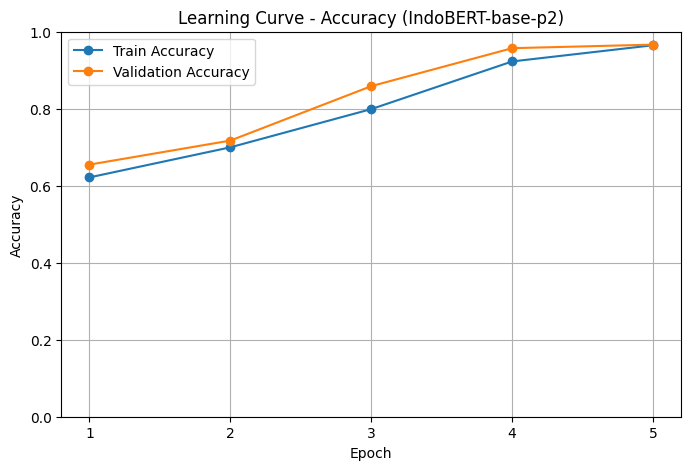


=== CLASSIFICATION REPORT VALIDASI: INDO-BERT P2 ===


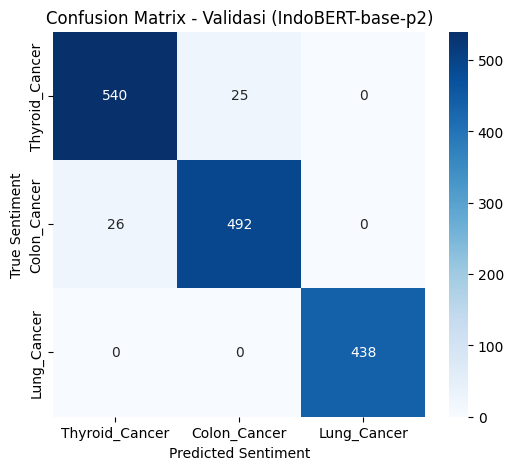

                precision    recall  f1-score   support

Thyroid_Cancer       0.95      0.96      0.95       565
  Colon_Cancer       0.95      0.95      0.95       518
   Lung_Cancer       1.00      1.00      1.00       438

      accuracy                           0.97      1521
     macro avg       0.97      0.97      0.97      1521
  weighted avg       0.97      0.97      0.97      1521


=== CLASSIFICATION REPORT TEST: INDO-BERT P2 ===


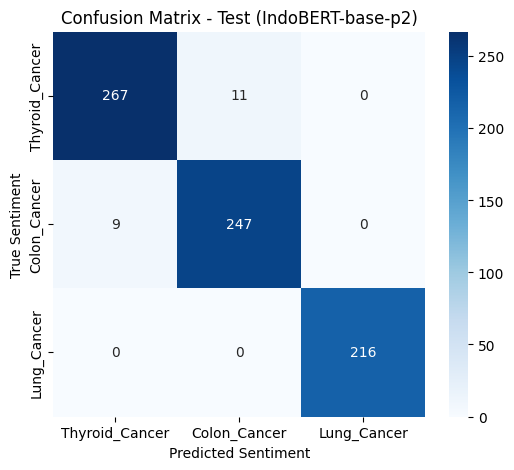

                precision    recall  f1-score   support

Thyroid_Cancer       0.97      0.96      0.96       278
  Colon_Cancer       0.96      0.96      0.96       256
   Lung_Cancer       1.00      1.00      1.00       216

      accuracy                           0.97       750
     macro avg       0.97      0.98      0.97       750
  weighted avg       0.97      0.97      0.97       750



In [22]:
# Label sesuai urutan distribusi data
labels = ['Thyroid_Cancer', 'Colon_Cancer', 'Lung_Cancer']

# ======== PLOT AKURASI ========
epochs = range(1, len(history['train_acc']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Learning Curve - Accuracy (IndoBERT-base-p2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

# ======== PLOT LOSS (jika tersedia) ========
if 'train_loss' in history and 'val_loss' in history:
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Learning Curve - Loss (IndoBERT-base-p2)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    plt.show()

# ======== CONFUSION MATRIX & REPORT VALIDASI ========
print("\n=== CLASSIFICATION REPORT VALIDASI: INDO-BERT P2 ===")
cm_val = confusion_matrix(val_real, val_pred, labels=labels)
df_cm_val = pd.DataFrame(cm_val, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(df_cm_val, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Validasi (IndoBERT-base-p2)")
plt.ylabel("True Sentiment")
plt.xlabel("Predicted Sentiment")
plt.show()

print(classification_report(val_real, val_pred, labels=labels, target_names=labels))

# ======== CONFUSION MATRIX & REPORT TEST ========
print("\n=== CLASSIFICATION REPORT TEST: INDO-BERT P2 ===")
cm_test = confusion_matrix(test_real, test_pred, labels=labels)
df_cm_test = pd.DataFrame(cm_test, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(df_cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test (IndoBERT-base-p2)")
plt.ylabel("True Sentiment")
plt.xlabel("Predicted Sentiment")
plt.show()

print(classification_report(test_real, test_pred, labels=labels, target_names=labels))